In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=10000, n_features=500, 
                           n_informative=50, n_repeated=0, 
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=3)

In [4]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression().fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8413
Test score: 0.8056


In [5]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]  # этот шрифт у вас есть


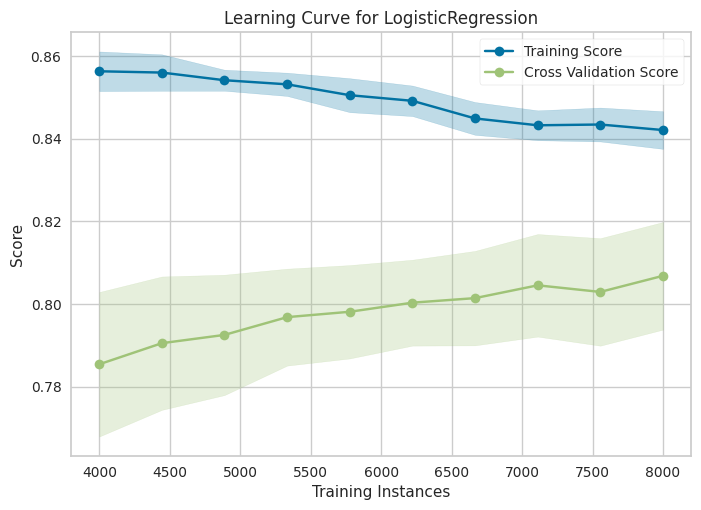

In [6]:
from yellowbrick.model_selection import LearningCurve

visualizer = LearningCurve(
    LogisticRegression(), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show() 

In [7]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=1000000).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.7724
Test score: 0.7712


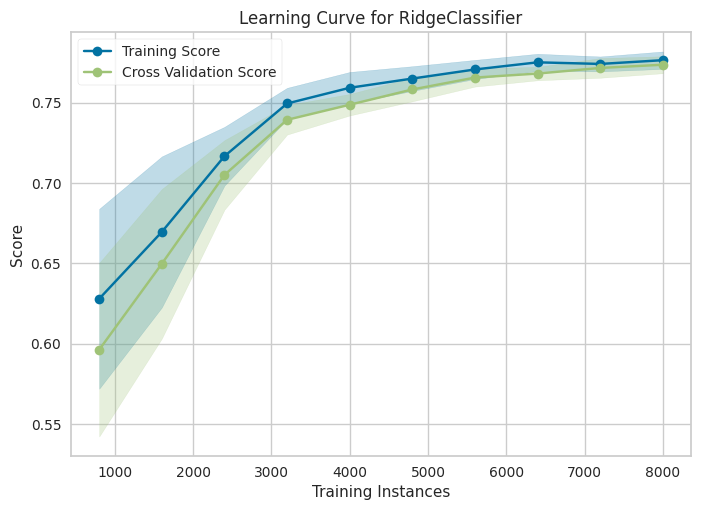

In [8]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

Кандидаты (test acc ≥ 0.8200):
     alpha    Train     Test      Gap
--------------------------------------
     13257  0.8356  0.8200  0.0156
     15999  0.8345  0.8212  0.0133
     19307  0.8336  0.8216  0.0120
     23300  0.8319  0.8220  0.0099
     28118  0.8308  0.8220  0.0088 ◄

Выбрана alpha = 28118  (Test acc: 0.8220, Gap: 0.0088)


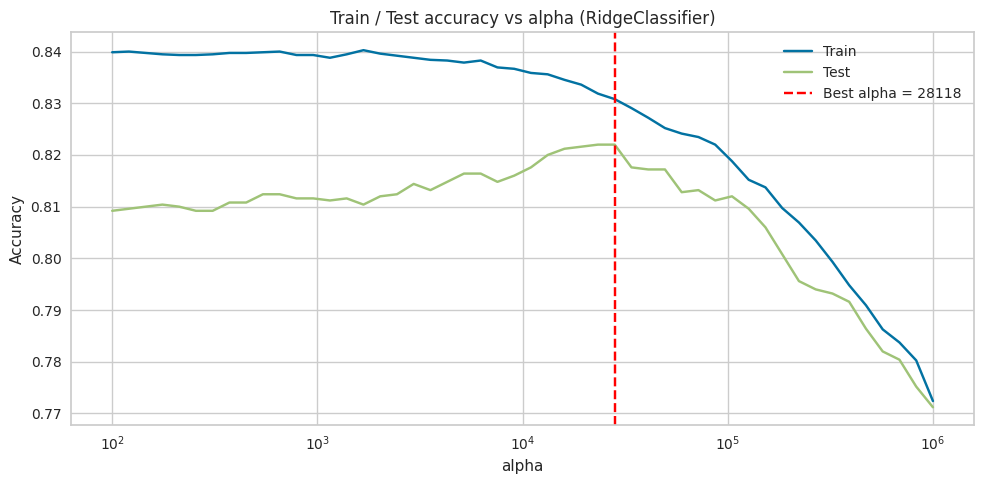

In [9]:
from sklearn.linear_model import RidgeClassifier

alphas = np.logspace(2, 6, 50)
trains = []
tests  = []

for a in alphas:
    ridge = RidgeClassifier(alpha=a).fit(X_train, y_train)
    trains.append(ridge.score(X_train, y_train))
    tests.append(ridge.score(X_test, y_test))

trains = np.array(trains)
tests  = np.array(tests)

# ---- Умный выбор alpha ----
# 1) Находим максимальный test accuracy
best_test = tests.max()

# 2) Берём все alpha, где test accuracy отличается от максимума
#    не более чем на 0.002 (т.е. практически такой же)
tolerance = 0.002
mask = tests >= best_test - tolerance
candidates = np.where(mask)[0]

# 3) Среди кандидатов выбираем ту alpha, где разрыв train−test минимален
#    (модель наиболее стабильна / не переобучена)
gaps = trains[candidates] - tests[candidates]
best_idx = candidates[np.argmin(gaps)]

print("Кандидаты (test acc ≥ {:.4f}):".format(best_test - tolerance))
print(f"{'alpha':>10}  {'Train':>7}  {'Test':>7}  {'Gap':>7}")
print("-" * 38)
for idx in candidates:
    marker = " ◄" if idx == best_idx else ""
    print(f"{alphas[idx]:>10.0f}  {trains[idx]:.4f}  {tests[idx]:.4f}  {trains[idx]-tests[idx]:.4f}{marker}")

print(f"\nВыбрана alpha = {alphas[best_idx]:.0f}  "
      f"(Test acc: {tests[best_idx]:.4f}, Gap: {trains[best_idx]-tests[best_idx]:.4f})")

# ---- График ----
plt.figure(figsize=(10, 5))
plt.plot(alphas, trains, label='Train')
plt.plot(alphas, tests,  label='Test')
plt.axvline(alphas[best_idx], color='red', linestyle='--',
            label=f'Best alpha = {alphas[best_idx]:.0f}')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Accuracy')
plt.title('Train / Test accuracy vs alpha (RidgeClassifier)')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=26500).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8311
Test score: 0.8228


## 1

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# --- LogisticRegression (без регуляризации) ---
lr_base = LogisticRegression().fit(X_train, y_train)

y_train_pred_base = lr_base.predict(X_train)
y_test_pred_base = lr_base.predict(X_test)

print("=== LogisticRegression ===")
print(f"  Train  — Precision: {precision_score(y_train, y_train_pred_base):.4f}  "
      f"Recall: {recall_score(y_train, y_train_pred_base):.4f}  "
      f"F1: {f1_score(y_train, y_train_pred_base):.4f}")
print(f"  Test   — Precision: {precision_score(y_test, y_test_pred_base):.4f}  "
      f"Recall: {recall_score(y_test, y_test_pred_base):.4f}  "
      f"F1: {f1_score(y_test, y_test_pred_base):.4f}")

# --- RidgeClassifier (сильная регуляризация, alpha=1 000 000) — недообучение ---
ridge_under = RidgeClassifier(alpha=1_000_000).fit(X_train, y_train)

y_train_pred_under = ridge_under.predict(X_train)
y_test_pred_under = ridge_under.predict(X_test)

print("\n=== RidgeClassifier (alpha=1 000 000) — недообучение ===")
print(f"  Train  — Precision: {precision_score(y_train, y_train_pred_under):.4f}  "
      f"Recall: {recall_score(y_train, y_train_pred_under):.4f}  "
      f"F1: {f1_score(y_train, y_train_pred_under):.4f}")
print(f"  Test   — Precision: {precision_score(y_test, y_test_pred_under):.4f}  "
      f"Recall: {recall_score(y_test, y_test_pred_under):.4f}  "
      f"F1: {f1_score(y_test, y_test_pred_under):.4f}")

# --- RidgeClassifier (оптимальная alpha=26 500) ---
ridge_opt = RidgeClassifier(alpha=26_500).fit(X_train, y_train)

y_train_pred_opt = ridge_opt.predict(X_train)
y_test_pred_opt = ridge_opt.predict(X_test)

print("\n=== RidgeClassifier (alpha=26 500) — оптимум ===")
print(f"  Train  — Precision: {precision_score(y_train, y_train_pred_opt):.4f}  "
      f"Recall: {recall_score(y_train, y_train_pred_opt):.4f}  "
      f"F1: {f1_score(y_train, y_train_pred_opt):.4f}")
print(f"  Test   — Precision: {precision_score(y_test, y_test_pred_opt):.4f}  "
      f"Recall: {recall_score(y_test, y_test_pred_opt):.4f}  "
      f"F1: {f1_score(y_test, y_test_pred_opt):.4f}")

# --- Подробный classification_report для оптимальной модели ---
print("\n=== Classification Report (RidgeClassifier, alpha=26 500, Test) ===")
print(classification_report(y_test, y_test_pred_opt))

=== LogisticRegression ===
  Train  — Precision: 0.8337  Recall: 0.8515  F1: 0.8425
  Test   — Precision: 0.8069  Recall: 0.8056  F1: 0.8062

=== RidgeClassifier (alpha=1 000 000) — недообучение ===
  Train  — Precision: 0.7683  Recall: 0.7780  F1: 0.7731
  Test   — Precision: 0.7678  Recall: 0.7801  F1: 0.7739

=== RidgeClassifier (alpha=26 500) — оптимум ===
  Train  — Precision: 0.8174  Recall: 0.8513  F1: 0.8340
  Train  — Precision: 0.7683  Recall: 0.7780  F1: 0.7731
  Test   — Precision: 0.7678  Recall: 0.7801  F1: 0.7739

=== RidgeClassifier (alpha=26 500) — оптимум ===
  Train  — Precision: 0.8174  Recall: 0.8513  F1: 0.8340
  Test   — Precision: 0.8123  Recall: 0.8414  F1: 0.8266

=== Classification Report (RidgeClassifier, alpha=26 500, Test) ===
              precision    recall  f1-score   support

           0       0.83      0.80      0.82      1245
           1       0.81      0.84      0.83      1255

    accuracy                           0.82      2500
   macro avg   

## 2. Диагностика модели классификации — SVM, KNN, Decision Tree

Исследуем влияние гиперпараметров на недо- и переобучение для трёх моделей:
- **SVM (SVC)** — параметр C
- **KNN** — количество соседей n_neighbors
- **Decision Tree** — глубина дерева max_depth

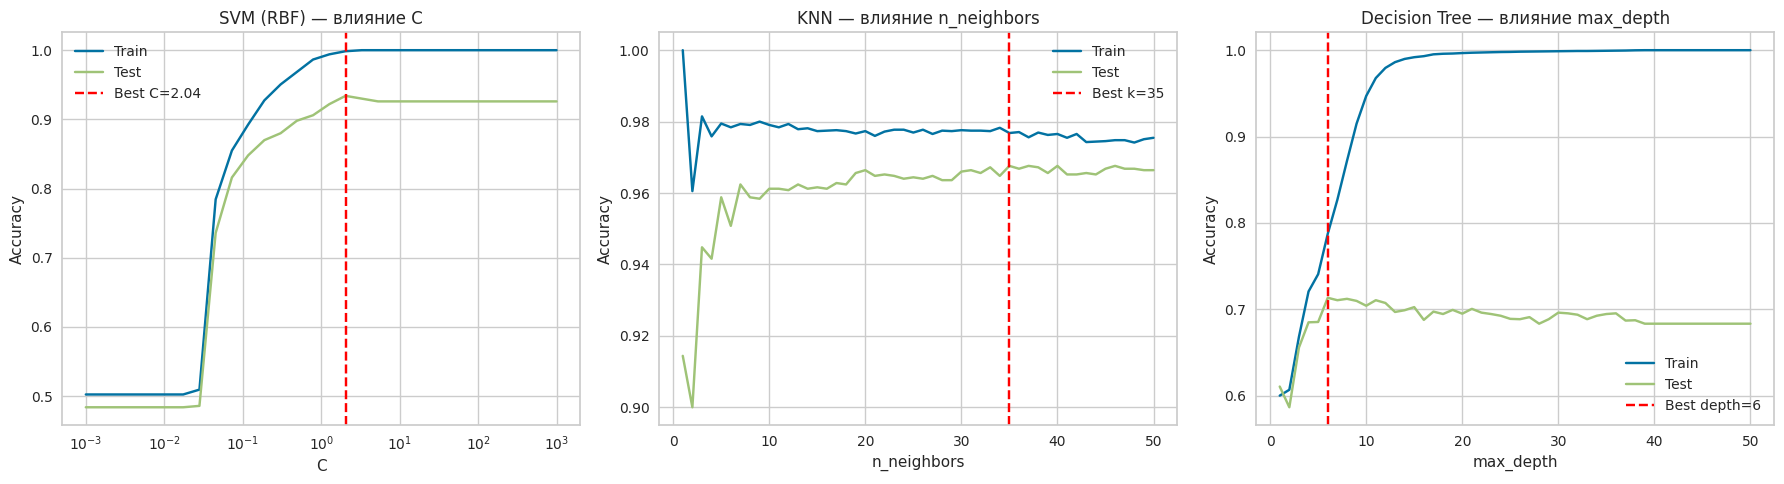

SVM:  лучший C = 2.0434, Test acc = 0.9340
KNN:  лучший k = 35, Test acc = 0.9676
DTree: лучшая глубина = 6, Test acc = 0.7132


In [12]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# =============================================
# 2a. SVM — влияние параметра C
# =============================================
C_values = np.logspace(-3, 3, 30)
svm_trains, svm_tests = [], []

for c in C_values:
    svm = SVC(C=c, kernel='rbf', random_state=42)
    # Используем подвыборку для скорости (SVM медленный на 10k)
    idx_tr = np.random.RandomState(0).choice(len(X_train), 2000, replace=False)
    idx_te = np.random.RandomState(0).choice(len(X_test), 500, replace=False)
    svm.fit(X_train[idx_tr], y_train[idx_tr])
    svm_trains.append(svm.score(X_train[idx_tr], y_train[idx_tr]))
    svm_tests.append(svm.score(X_test[idx_te], y_test[idx_te]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(C_values, svm_trains, label='Train')
axes[0].plot(C_values, svm_tests,  label='Test')
best_c = C_values[np.argmax(svm_tests)]
axes[0].axvline(best_c, color='red', ls='--', label=f'Best C={best_c:.2f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('C')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('SVM (RBF) — влияние C')
axes[0].legend()

# =============================================
# 2b. KNN — влияние n_neighbors
# =============================================
k_values = list(range(1, 51))
knn_trains, knn_tests = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_trains.append(knn.score(X_train, y_train))
    knn_tests.append(knn.score(X_test, y_test))

axes[1].plot(k_values, knn_trains, label='Train')
axes[1].plot(k_values, knn_tests,  label='Test')
best_k = k_values[np.argmax(knn_tests)]
axes[1].axvline(best_k, color='red', ls='--', label=f'Best k={best_k}')
axes[1].set_xlabel('n_neighbors')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('KNN — влияние n_neighbors')
axes[1].legend()

# =============================================
# 2c. Decision Tree — влияние max_depth
# =============================================
depths = list(range(1, 51))
dt_trains, dt_tests = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    dt_trains.append(dt.score(X_train, y_train))
    dt_tests.append(dt.score(X_test, y_test))

axes[2].plot(depths, dt_trains, label='Train')
axes[2].plot(depths, dt_tests,  label='Test')
best_d = depths[np.argmax(dt_tests)]
axes[2].axvline(best_d, color='red', ls='--', label=f'Best depth={best_d}')
axes[2].set_xlabel('max_depth')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Decision Tree — влияние max_depth')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"SVM:  лучший C = {best_c:.4f}, Test acc = {max(svm_tests):.4f}")
print(f"KNN:  лучший k = {best_k}, Test acc = {max(knn_tests):.4f}")
print(f"DTree: лучшая глубина = {best_d}, Test acc = {max(dt_tests):.4f}")

## 3. Lasso на датасете Boston

Кривые обучения для переобученной, недообученной и качественной модели Lasso.
Поиск оптимального значения параметра регуляризации alpha.

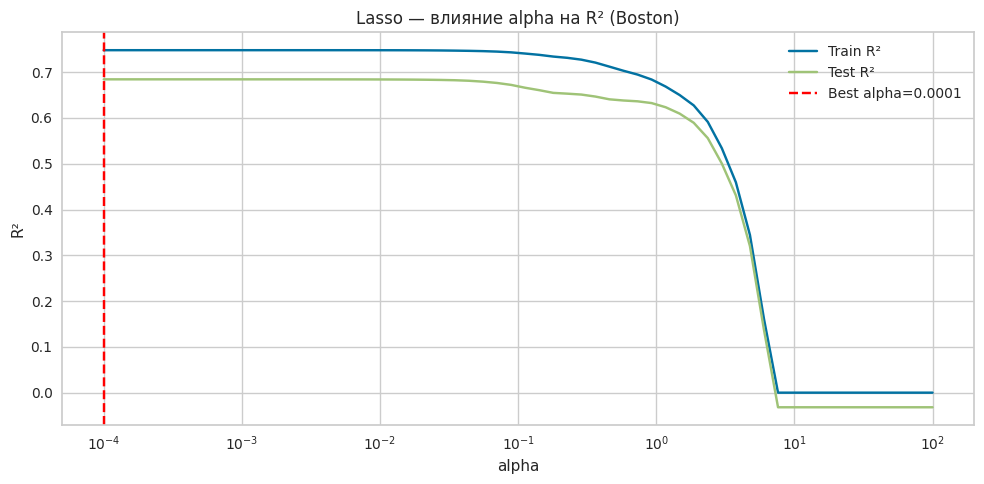

Лучший alpha: 0.0001, Test R²: 0.6844


In [13]:
from sklearn.linear_model import Lasso
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from yellowbrick.model_selection import LearningCurve

# Загрузка датасета Boston (OpenML id=531)
boston = fetch_openml(data_id=531, as_frame=False)
X_bos, y_bos = boston.data, boston.target

scaler = StandardScaler()
X_bos_sc = scaler.fit_transform(X_bos)
X_bos_tr, X_bos_te, y_bos_tr, y_bos_te = train_test_split(
    X_bos_sc, y_bos, test_size=0.25, random_state=42)

# --- Перебор alpha для Lasso ---
lasso_alphas = np.logspace(-4, 2, 60)
lasso_trains, lasso_tests = [], []

for a in lasso_alphas:
    mdl = Lasso(alpha=a, max_iter=10000).fit(X_bos_tr, y_bos_tr)
    lasso_trains.append(mdl.score(X_bos_tr, y_bos_tr))
    lasso_tests.append(mdl.score(X_bos_te, y_bos_te))

best_lasso_idx = np.argmax(lasso_tests)
best_lasso_alpha = lasso_alphas[best_lasso_idx]

plt.figure(figsize=(10, 5))
plt.plot(lasso_alphas, lasso_trains, label='Train R²')
plt.plot(lasso_alphas, lasso_tests,  label='Test R²')
plt.axvline(best_lasso_alpha, color='red', ls='--',
            label=f'Best alpha={best_lasso_alpha:.4f}')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R²')
plt.title('Lasso — влияние alpha на R² (Boston)')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Лучший alpha: {best_lasso_alpha:.4f}, Test R²: {lasso_tests[best_lasso_idx]:.4f}")

/home/fampkin/Desktop/ML/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.983e+00, tolerance: 2.094e-02
  model = cd_fast.enet_coordinate_descent(
/home/fampkin/Desktop/ML/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.922e+01, tolerance: 1.430e-01
  model = cd_fast.enet_coordinate_descent(
/home/fampkin/Desktop/ML/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing 

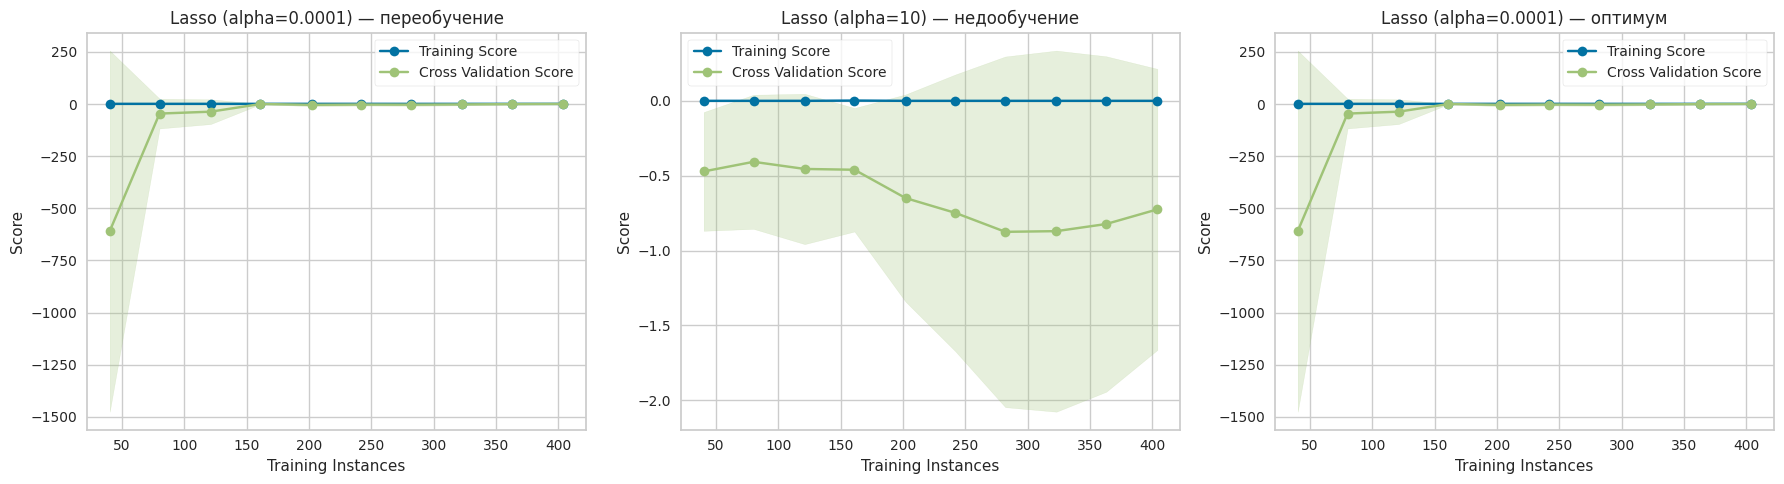

In [14]:
# Кривые обучения для трёх режимов Lasso
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Переобучение — alpha очень маленький (слабая регуляризация)
viz1 = LearningCurve(
    Lasso(alpha=0.0001, max_iter=10000), scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), ax=axes[0]
)
viz1.fit(X_bos_sc, y_bos)
viz1.finalize()
axes[0].set_title('Lasso (alpha=0.0001) — переобучение')

# Недообучение — alpha очень большой (сильная регуляризация)
viz2 = LearningCurve(
    Lasso(alpha=10, max_iter=10000), scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), ax=axes[1]
)
viz2.fit(X_bos_sc, y_bos)
viz2.finalize()
axes[1].set_title('Lasso (alpha=10) — недообучение')

# Оптимум
viz3 = LearningCurve(
    Lasso(alpha=best_lasso_alpha, max_iter=10000), scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), ax=axes[2]
)
viz3.fit(X_bos_sc, y_bos)
viz3.finalize()
axes[2].set_title(f'Lasso (alpha={best_lasso_alpha:.4f}) — оптимум')

plt.tight_layout()
plt.show()

## 4. ElasticNet — влияние двух параметров регуляризации

Исследуем совместное влияние alpha и l1_ratio на качество модели ElasticNet (на синтетических данных классификации, преобразованных в регрессию).

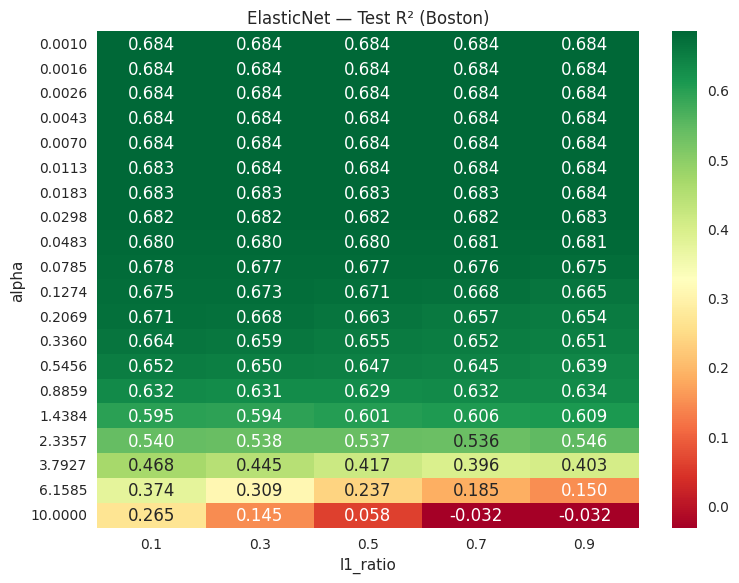

Лучшая комбинация: alpha=0.0010, l1_ratio=0.9, Test R²=0.6844


In [15]:
from sklearn.linear_model import ElasticNet

# Используем датасет Boston для ElasticNet (регрессия)
en_alphas = np.logspace(-3, 1, 20)
en_l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

results = np.zeros((len(en_alphas), len(en_l1_ratios)))

for i, a in enumerate(en_alphas):
    for j, lr in enumerate(en_l1_ratios):
        mdl = ElasticNet(alpha=a, l1_ratio=lr, max_iter=10000)
        mdl.fit(X_bos_tr, y_bos_tr)
        results[i, j] = mdl.score(X_bos_te, y_bos_te)

# Тепловая карта
fig, ax = plt.subplots(figsize=(8, 6))
import seaborn as sns
sns.heatmap(results, annot=True, fmt='.3f',
            xticklabels=[f'{r:.1f}' for r in en_l1_ratios],
            yticklabels=[f'{a:.4f}' for a in en_alphas],
            cmap='RdYlGn', ax=ax)
ax.set_xlabel('l1_ratio')
ax.set_ylabel('alpha')
ax.set_title('ElasticNet — Test R² (Boston)')
plt.tight_layout()
plt.show()

# Лучшая комбинация
best_pos = np.unravel_index(results.argmax(), results.shape)
print(f"Лучшая комбинация: alpha={en_alphas[best_pos[0]]:.4f}, "
      f"l1_ratio={en_l1_ratios[best_pos[1]]:.1f}, "
      f"Test R²={results[best_pos]:.4f}")

## 5. Decision Tree — оптимальная глубина + метрика F1

Кривые регуляризации для полного датасета синтетических данных.
Поиск оптимальной глубины и оценка качества с метриками Accuracy и F1.

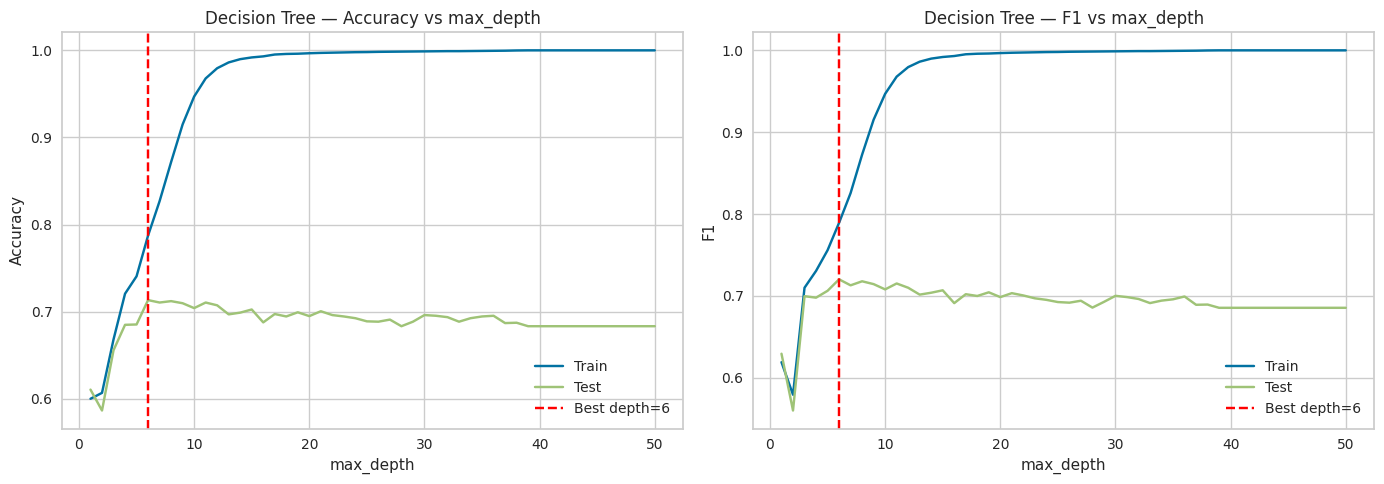

По Accuracy: лучшая глубина = 6, Test Acc = 0.7132
По F1:       лучшая глубина = 6, Test F1  = 0.7202

=== Classification Report (DecisionTree, depth=6, Test) ===
              precision    recall  f1-score   support

           0       0.72      0.69      0.71      1245
           1       0.71      0.74      0.72      1255

    accuracy                           0.71      2500
   macro avg       0.71      0.71      0.71      2500
weighted avg       0.71      0.71      0.71      2500


=== Classification Report (DecisionTree, depth=6, Test) ===
              precision    recall  f1-score   support

           0       0.72      0.69      0.71      1245
           1       0.71      0.74      0.72      1255

    accuracy                           0.71      2500
   macro avg       0.71      0.71      0.71      2500
weighted avg       0.71      0.71      0.71      2500



In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

depths = list(range(1, 51))
dt_acc_train, dt_acc_test = [], []
dt_f1_train,  dt_f1_test  = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    
    y_tr_pred = dt.predict(X_train)
    y_te_pred = dt.predict(X_test)
    
    dt_acc_train.append(dt.score(X_train, y_train))
    dt_acc_test.append(dt.score(X_test, y_test))
    dt_f1_train.append(f1_score(y_train, y_tr_pred))
    dt_f1_test.append(f1_score(y_test, y_te_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(depths, dt_acc_train, label='Train')
axes[0].plot(depths, dt_acc_test,  label='Test')
best_d_acc = depths[np.argmax(dt_acc_test)]
axes[0].axvline(best_d_acc, color='red', ls='--', label=f'Best depth={best_d_acc}')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Decision Tree — Accuracy vs max_depth')
axes[0].legend()

# F1
axes[1].plot(depths, dt_f1_train, label='Train')
axes[1].plot(depths, dt_f1_test,  label='Test')
best_d_f1 = depths[np.argmax(dt_f1_test)]
axes[1].axvline(best_d_f1, color='red', ls='--', label=f'Best depth={best_d_f1}')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('F1')
axes[1].set_title('Decision Tree — F1 vs max_depth')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"По Accuracy: лучшая глубина = {best_d_acc}, "
      f"Test Acc = {max(dt_acc_test):.4f}")
print(f"По F1:       лучшая глубина = {best_d_f1}, "
      f"Test F1  = {max(dt_f1_test):.4f}")

# Оценка лучшей модели
dt_best = DecisionTreeClassifier(max_depth=best_d_f1, random_state=42).fit(X_train, y_train)
y_pred_best = dt_best.predict(X_test)
print(f"\n=== Classification Report (DecisionTree, depth={best_d_f1}, Test) ===")
print(classification_report(y_test, y_pred_best))

## 6. Анализ на реальных датасетах OpenML

Для каждого датасета: перебор гиперпараметра (alpha для RidgeClassifier), построение кривой train/test accuracy, нахождение оптимального значения.

✓ phoneme                    best alpha=      0.01  test acc=0.7543  samples=5404, features=5
✓ banknote-authentication    best alpha=     49.24  test acc=0.9854  samples=1372, features=4
✓ banknote-authentication    best alpha=     49.24  test acc=0.9854  samples=1372, features=4
✓ delta_ailerons             best alpha=    203.09  test acc=0.8378  samples=145, features=94
✓ delta_ailerons             best alpha=    203.09  test acc=0.8378  samples=145, features=94
✓ mammography                best alpha=      0.01  test acc=0.9814  samples=11183, features=6
✓ mammography                best alpha=      0.01  test acc=0.9814  samples=11183, features=6
✗ electricity: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
✗ electricity: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
✓ 

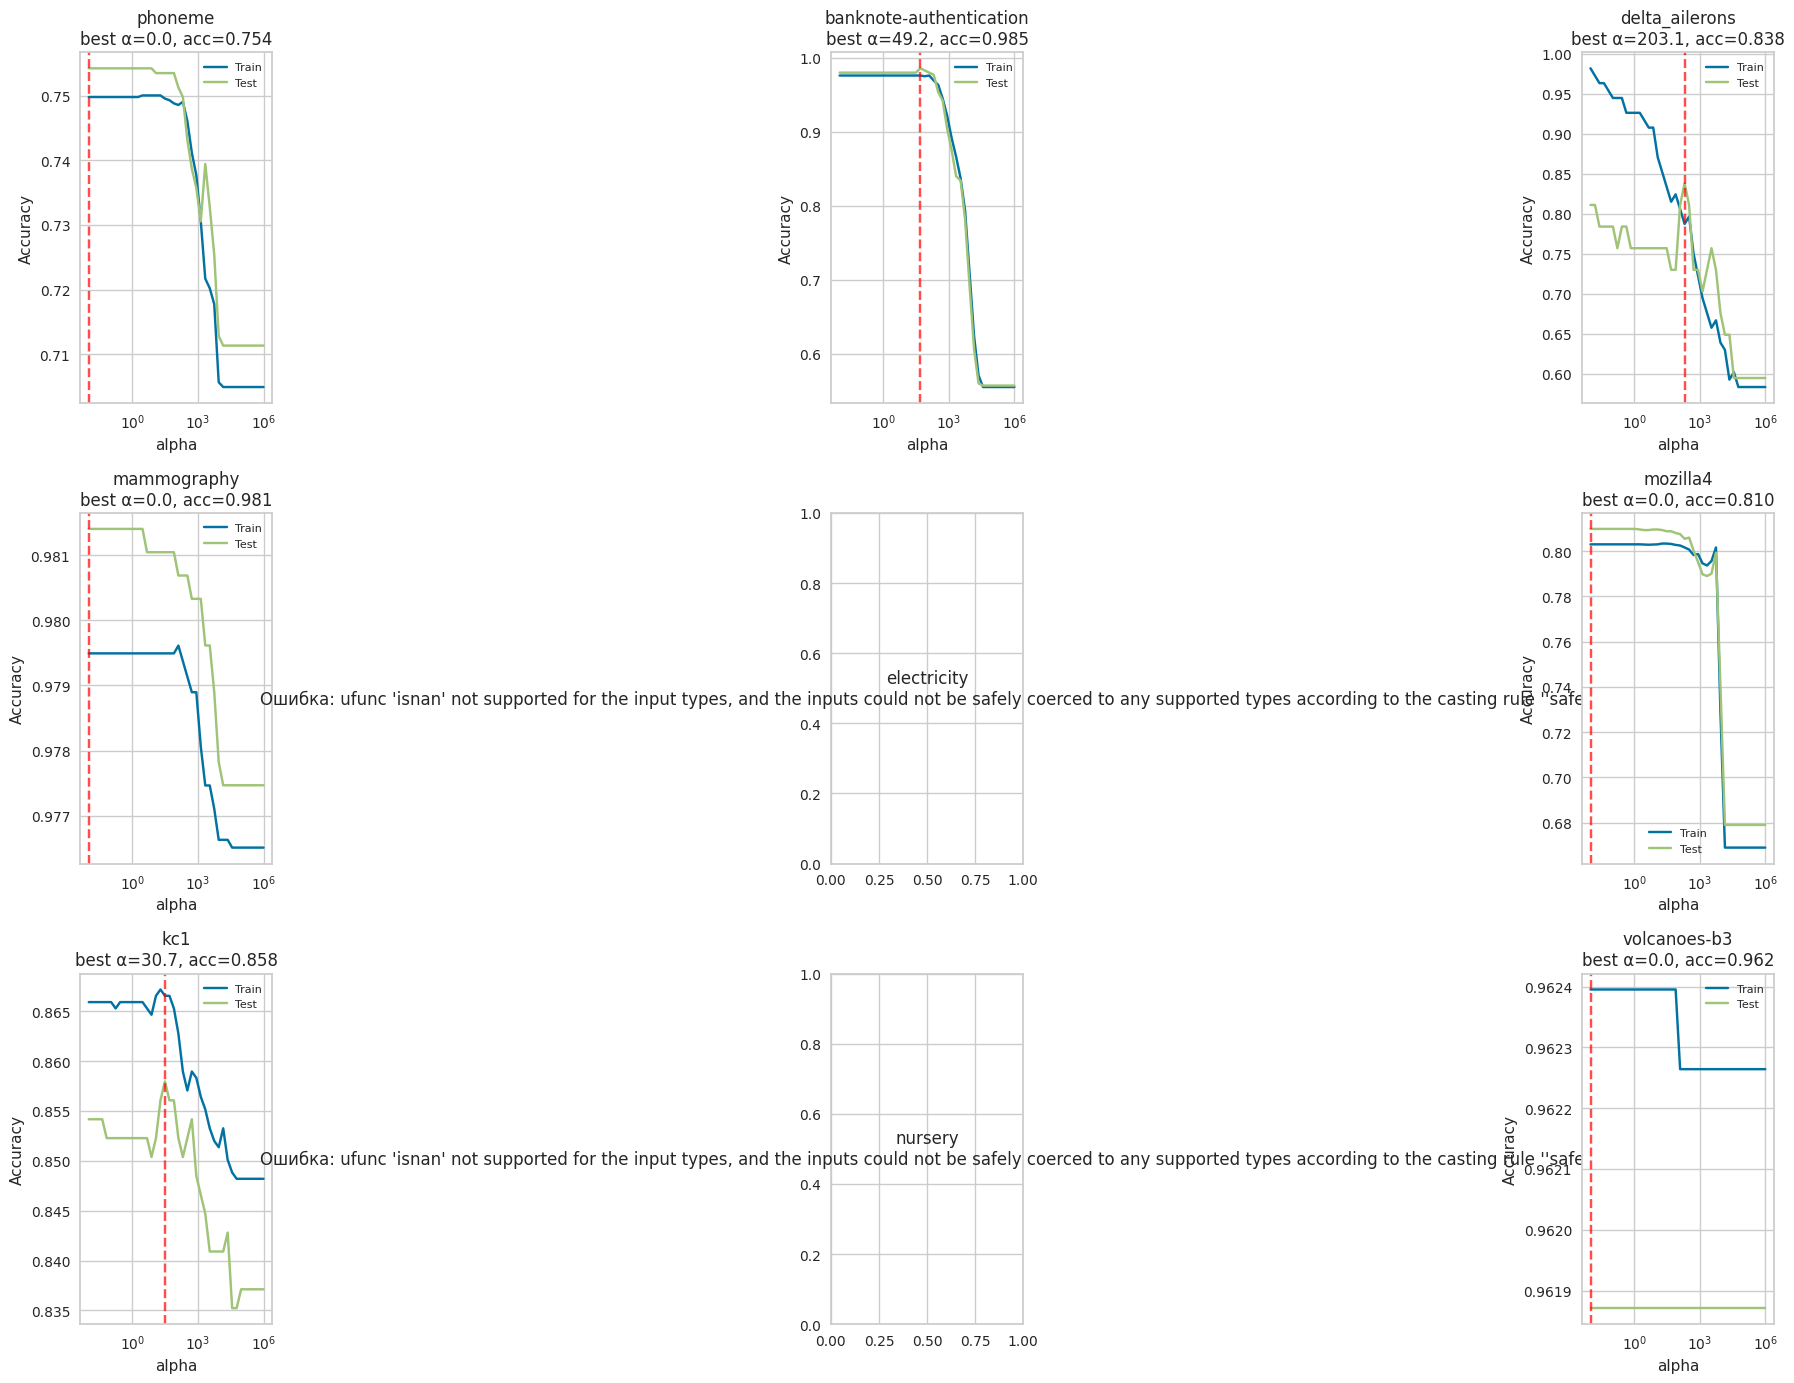

In [17]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import RidgeClassifier
import warnings
warnings.filterwarnings('ignore')

datasets = {
    'phoneme': 1489,
    'banknote-authentication': 1462,
    'delta_ailerons': 1066,
    'mammography': 310,
    'electricity': 151,
    'mozilla4': 1046,
    'kc1': 1067,          # kropt недоступен, заменяем на kc1
    'nursery': 26,
    'volcanoes-b3': 1531,
}

n_ds = len(datasets)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for idx, (name, did) in enumerate(datasets.items()):
    ax = axes[idx]
    try:
        data = fetch_openml(data_id=did, as_frame=False)
        X_d, y_d = data.data, data.target
        
        # Encode target if needed
        if y_d.dtype == object or y_d.dtype.kind in ('U', 'S'):
            y_d = LabelEncoder().fit_transform(y_d)
        y_d = y_d.astype(int)
        
        # Handle NaN
        if np.any(np.isnan(X_d)):
            from sklearn.impute import SimpleImputer
            X_d = SimpleImputer().fit_transform(X_d)
        
        scaler = StandardScaler()
        X_d = scaler.fit_transform(X_d)
        
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_d, y_d, test_size=0.25, random_state=42)
        
        alphas = np.logspace(-2, 6, 40)
        tr_scores, te_scores = [], []
        
        for a in alphas:
            mdl = RidgeClassifier(alpha=a).fit(X_tr, y_tr)
            tr_scores.append(mdl.score(X_tr, y_tr))
            te_scores.append(mdl.score(X_te, y_te))
        
        best_i = np.argmax(te_scores)
        
        ax.plot(alphas, tr_scores, label='Train')
        ax.plot(alphas, te_scores, label='Test')
        ax.axvline(alphas[best_i], color='red', ls='--', alpha=0.7)
        ax.set_xscale('log')
        ax.set_xlabel('alpha')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{name}\nbest α={alphas[best_i]:.1f}, '
                     f'acc={te_scores[best_i]:.3f}')
        ax.legend(fontsize=8)
        
        print(f"✓ {name:25s}  best alpha={alphas[best_i]:>10.2f}  "
              f"test acc={te_scores[best_i]:.4f}  "
              f"samples={X_d.shape[0]}, features={X_d.shape[1]}")
    except Exception as e:
        ax.text(0.5, 0.5, f'{name}\nОшибка: {e}',
                ha='center', va='center', transform=ax.transAxes)
        print(f"✗ {name}: {e}")

plt.tight_layout()
plt.show()